## Subset anndata for cell2location

Spatial data is only Control + Bleo on day 21 (so we don't need day10 and treatments)

In [1]:
import scanpy as sc
import numpy as np

In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/'

In [3]:
## load anndata object
adata = sc.read(adata_dir + '240731_GLPG_annotated.h5ad')

In [4]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

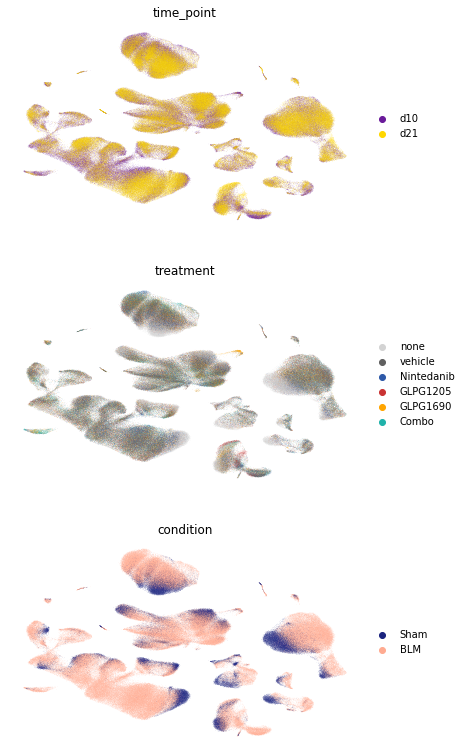

In [5]:
## short UMAP
sc.pl.umap(adata, color = ['time_point','treatment','condition'], frameon = False, ncols = 1)

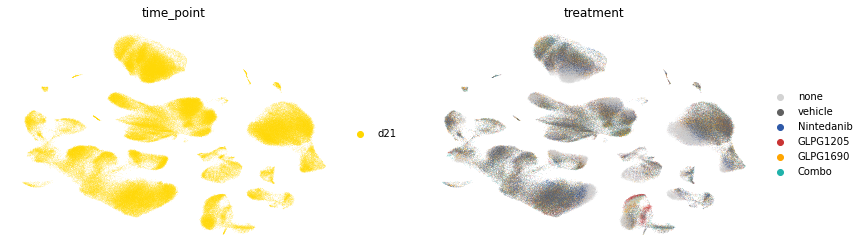

In [6]:
## subset adata
adata = adata[adata.obs['time_point'] == 'd21']
## check with UMAP
sc.pl.umap(adata, color = ['time_point','treatment'], frameon = False)

In [7]:
## rename treatmentlabel
treatment_conversion = {'none' : 'PBS',
                        'vehicle' : 'Bleo',
                        'Nintedanib' : 'Bleo+Nintedanib',
                        'GLPG1205' : 'Bleo+GLPG1205',
                        'GLPG1690' : 'Bleo+GLPG1690',
                        'Combo' : 'Bleo+Combo'
}
adata.obs['treatment'] = [treatment_conversion[tt] for tt in adata.obs['treatment']]

Trying to set attribute `.obs` of view, copying.


/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1236: ImplicitModificationWarning: Initializing view as actual.
  warnings.warn(
Trying to set attribute `.obs` of view, copying.
... storing 'treatment' as categorical


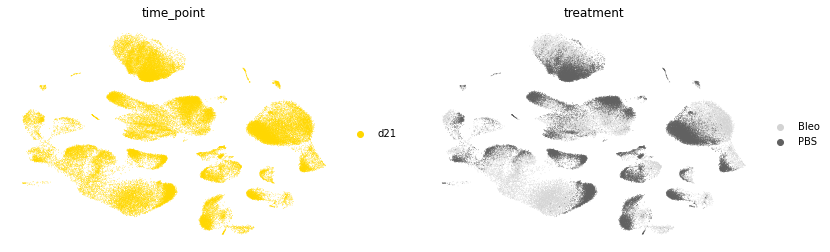

In [8]:
## subset adata
adata = adata[adata.obs['treatment'].isin(['PBS','Bleo'])]
## check with UMAP
sc.pl.umap(adata, color = ['time_point','treatment'], frameon = False)

In [9]:
adata

AnnData object with n_obs × n_vars = 72828 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

In [10]:
## save subset
adata.write('/mnt/smb2/Niklas/GLPG_data_temp/240913_GLPG_PBS_Bleo_d21.h5ad')